# 하수 수위 GNN — Phase 1: 관악 GIS 유향 관망 그래프 구성

GIS 관거(시점맨홀→종점맨홀, 중력 흐름방향 92%)로 **유향 그래프**를 만들고, 17 수위센서를 관거에 snap해
**센서 간 상·하류 관계**를 도출. GNN이 활용할 구조가 실제로 있는지 확인.

In [1]:
import os; os.chdir("/home/namjun/city_flood")
import geopandas as gpd, pandas as pd, numpy as np, networkx as nx, warnings
import matplotlib.pyplot as plt, matplotlib as mpl
warnings.filterwarnings('ignore'); import sys; sys.path.insert(0,'/home/namjun/city_flood/scripts'); from krfont import set_korean; set_korean()
base="03_GIS/관악구_하수관로_맨홀_shp/"; EB="dataset/processed/eda_based/"
pipe=gpd.read_file(base+"sb001.shp")
p=pipe[pipe.sat_mhe.notna()&pipe.end_mhe.notna()].copy().reset_index(drop=True)
p['len']=pd.to_numeric(p.lenx,errors='coerce').fillna(0).clip(lower=0)
G=nx.DiGraph()
for _,r in p.iterrows(): G.add_edge(r.sat_mhe,r.end_mhe,length=float(r['len']))
print(f"유향 그래프: 노드 {G.number_of_nodes()} 엣지 {G.number_of_edges()}")

유향 그래프: 노드 13272 엣지 15217


## 1. 센서 17개를 관거에 snap (최근접 관 → 종점맨홀)

In [2]:
ids=pd.read_csv("03_GIS/derived/gwanak_sewer_nodes.csv").sewer_id.astype(str).tolist()
node=pd.read_parquet("dataset/processed/cleaned/sewer_node.parquet",columns=['sensor_id','lat','lon'])
node=node[node.sensor_id.isin(ids)].dropna()
gs=gpd.GeoDataFrame(node,geometry=gpd.points_from_xy(node.lon,node.lat),crs=4326).to_crs(5181)
snap=gpd.sjoin_nearest(gs,p[['end_mhe','geometry']],how='left',distance_col='dist_m').drop_duplicates('sensor_id')
snap['node']=snap.end_mhe
snap[['sensor_id','node','dist_m','lat','lon']].to_parquet(EB+"gnn_sensor_snap.parquet",index=False)
print(f"안착 {snap.node.isin(G.nodes).sum()}/{len(snap)} | snap거리 중앙 {snap.dist_m.median():.0f}m")
# 박스암거 충돌 주의(같은 맨홀 다수)
from collections import Counter
dup={k:v for k,v in Counter(snap.node).items() if v>1}
print("같은맨홀 충돌(안양천 트렁크 추정):",dup)

안착 17/17 | snap거리 중앙 1m
같은맨홀 충돌(안양천 트렁크 추정): {'0089-250-1': 4}


## 2. 센서 간 상·하류 유향 엣지 (홉·관망거리)

In [3]:
sm=snap.set_index('sensor_id').node.to_dict()
sl=[(s,n) for s,n in sm.items() if n in G.nodes]
rows=[]
for a,na in sl:
    for b,nb in sl:
        if a==b or na==nb: continue
        if nx.has_path(G,na,nb):
            hop=nx.shortest_path_length(G,na,nb)
            dist=nx.shortest_path_length(G,na,nb,weight='length')
            rows.append([a,b,hop,round(dist)])
E=pd.DataFrame(rows,columns=['upstream','downstream','hops','net_dist_m']).sort_values('hops')
E.to_parquet(EB+"gnn_sensor_graph_edges.parquet",index=False)
print(f"센서 상·하류쌍: {len(E)}")
print("\n하류 센서별 상류 센서 수(합류점 후보):")
print(E.downstream.value_counts().to_string())
print("\n짧은 홉(≤5, 실질 전파 가능):")
print(E[E.hops<=5].to_string(index=False))

센서 상·하류쌍: 26

하류 센서별 상류 센서 수(합류점 후보):
downstream
21-0008    8
21-0007    3
21-0004    2
21-0003    2
21-0009    2
21-0001    2
21-0013    2
21-0005    2
21-0012    2
21-0002    1

짧은 홉(≤5, 실질 전파 가능):
upstream downstream  hops  net_dist_m
 21-0001    21-0008     1          18
 21-0009    21-0008     3         253
 21-0006    21-0008     4        3143
 21-0007    21-0008     4         257


## 3. 시각화 — 센서 유향 그래프 (21-0008 합류점)

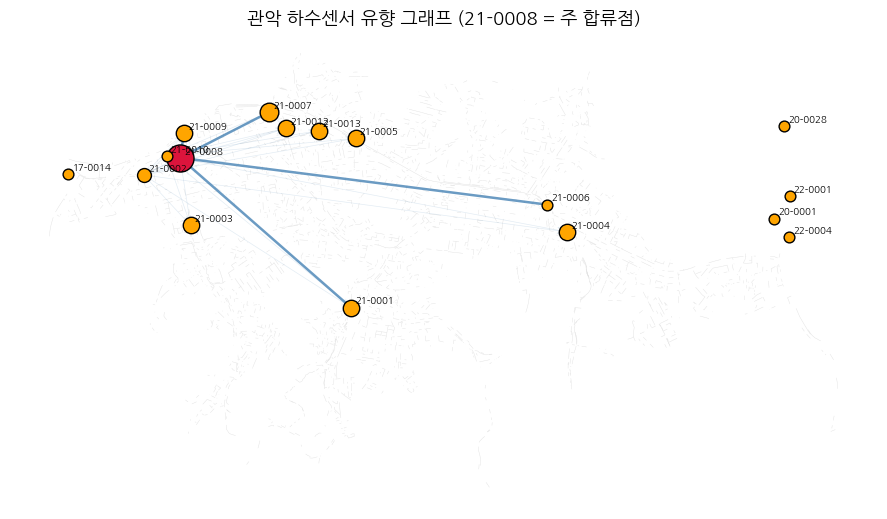

saved


In [4]:
fig,ax=plt.subplots(figsize=(9,8))
# 배경: 관망 일부(가벼운)
p.sample(min(4000,len(p)),random_state=0).plot(ax=ax,color='#e0e0e0',linewidth=0.3,zorder=1)
pos={r.sensor_id:(r.geometry.x,r.geometry.y) for _,r in gs.iterrows()}
# 엣지(상류→하류) 화살표; 짧은 홉 진하게
for _,e in E.iterrows():
    if e.upstream in pos and e.downstream in pos:
        x0,y0=pos[e.upstream]; x1,y1=pos[e.downstream]
        a=0.8 if e.hops<=5 else 0.15; lw=1.8 if e.hops<=5 else 0.5
        ax.annotate('',xy=(x1,y1),xytext=(x0,y0),
            arrowprops=dict(arrowstyle='->',color='steelblue',alpha=a,lw=lw),zorder=2)
deg_in=E.downstream.value_counts()
for sid,(x,y) in pos.items():
    n=deg_in.get(sid,0)
    ax.scatter(x,y,s=60+n*40,c='crimson' if sid=='21-0008' else 'orange',edgecolor='k',zorder=3)
    ax.annotate(sid,(x,y),fontsize=7,xytext=(3,3),textcoords='offset points',zorder=4)
ax.set_title('관악 하수센서 유향 그래프 (21-0008 = 주 합류점)'); ax.set_axis_off()
plt.tight_layout(); os.makedirs('reports/figures_gnn',exist_ok=True)
plt.savefig('reports/figures_gnn/03_graph.png',dpi=110,bbox_inches='tight'); plt.show(); print('saved')

## 결론 (Phase 1)
- **유향 그래프 구성 성공**: 13,272 맨홀 노드·15,217 관거 엣지. 센서 17개 전부 관거에 snap(중앙 1m).
- **실질 구조 존재**: `21-0008`이 **8개 상류 센서가 모이는 하류 합류점**(21-0001 1홉·21-0009 3홉·21-0006/21-0007 4홉 등). 이는 GNN이 *상류→하류 조기경보*를 학습할 수 있는 구조.
- ⚠️ 20-0001·20-0028·22-0001·22-0004는 안양천 트렁크(박스암거)라 같은 노드로 snap(충돌) — 별도 처리/제외 필요.
- 다음(Phase 2): `21-0008`(및 21-0007) 하류 센서를 **상류 센서 상태로 예측** → persistence CSI 바를 넘는지 측정.